# Acceptance Rate of Fix-Type Pull Requests (Own Data)

This notebook calculates the acceptance (merge) rate of **fix-type** pull requests from our own re-collected dataset
[mabujadallah/GitHub-Agentic-PR-Dataset](https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset).

Same methodology as the AIDev `pr_task_type` notebook: filter for fix type, keep only closed PRs.

## 1. Import Required Libraries

In [2]:
%pip install -q "pandas>=2.2" "pyarrow>=15.0" numpy matplotlib seaborn fsspec huggingface_hub jinja2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FONT_SCALE = 1.10
_BASE_FONT = 6.5

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=FONT_SCALE)

plt.rcParams.update({
    'font.serif': ['Times New Roman', 'Times'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 1.0,
    'axes.labelsize': _BASE_FONT,
    'axes.titlesize': _BASE_FONT,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.labelsize': _BASE_FONT,
    'ytick.labelsize': _BASE_FONT,
    'legend.fontsize': _BASE_FONT,
    'legend.title_fontsize': _BASE_FONT,
    'axes.edgecolor': 'grey',
    'figure.dpi': 300,
})

Note: you may need to restart the kernel to use updated packages.


## 2. Download and Load the Parquet Files

In [3]:
HF_BASE = "https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset/resolve/main"
url = f"{HF_BASE}/fix_classified_prs.parquet"

classified_df = pd.read_parquet(url, columns=['type', 'source', 'state', 'agent', 'merged_at', 'repo_name', 'number', 'created_at'])

# Keep only fix-type, closed, agent PRs (excl. Codex and human)
classified_df = classified_df[
    (classified_df['type'] == 'fix') &
    (classified_df['state'] == 'closed') &
    (classified_df['source'] == 'agent') &
    (classified_df['agent'] != 'OpenAI_Codex') &
    (classified_df['agent'] != 'human')
].copy()
classified_df['created_at'] = pd.to_datetime(classified_df['created_at'], errors='coerce')

print(f"Loaded & filtered fix_classified_prs from HuggingFace")
print(f"Shape: {classified_df.shape}")
print(f"Columns: {list(classified_df.columns)}")
print(f"\nTask type distribution:\n{classified_df['type'].value_counts()}")
print(f"\nSource distribution:\n{classified_df['source'].value_counts()}")
print(f"\nAgent distribution:\n{classified_df['agent'].value_counts()}")
print(f"\nTime range: {classified_df['created_at'].min()} → {classified_df['created_at'].max()}")

print(f"\nRandom sample (5 rows):")
classified_df.sample(5, random_state=42)

Loaded & filtered fix_classified_prs from HuggingFace
Shape: (116011, 8)
Columns: ['type', 'source', 'state', 'agent', 'merged_at', 'repo_name', 'number', 'created_at']

Task type distribution:
type
fix    116011
Name: count, dtype: int64

Source distribution:
source
agent    116011
Name: count, dtype: int64

Agent distribution:
agent
Claude_Code    43859
Cursor         37055
Copilot        26674
Devin           8423
Name: count, dtype: int64

Time range: 2024-12-01 00:26:13+00:00 → 2026-02-28 23:29:38+00:00

Random sample (5 rows):


,type,source,state,agent,merged_at,repo_name,number,created_at
1866068,fix,agent,closed,Copilot,2025-07-26T02:01:04Z,billlzzz10/notion-mcp-server,6,2025-07-26 01:47:01+00:00
29874,fix,agent,closed,Copilot,2026-02-03T00:30:38Z,openai/openai-dotnet,924,2026-01-31 00:49:31+00:00
1696615,fix,agent,closed,Copilot,2025-07-19T17:21:37Z,sayme89/sayme89.github.io,2,2025-07-17 15:39:12+00:00
1462243,fix,agent,closed,Devin,2025-05-13T07:40:17Z,brianklai/juice-shop-dev,121,2025-05-13 07:24:23+00:00
19338,fix,agent,closed,Claude_Code,2025-05-09T00:34:10Z,thefrontside/effection,1001,2025-05-08 17:37:52+00:00


## 3. Filter to AIDev-Overlapping PRs (Apple-to-Apple)

In [4]:
# Load AIDev fix PRs to build match keys
pr_df = pd.read_parquet("pull_request.parquet", columns=['id', 'repo_url', 'number', 'state', 'agent', 'merged_at', 'created_at'])
pr_task = pd.read_parquet("pr_task_type.parquet", columns=['id', 'type'])

# Derive repo_name from repo_url
pr_df['repo_name'] = pr_df['repo_url'].str.replace("https://api.github.com/repos/", "", regex=False)

aidev_fix = pr_task[pr_task['type'] == 'fix']
aidev = pd.merge(pr_df[['id', 'repo_name', 'number', 'state', 'agent', 'merged_at', 'created_at']], 
                 aidev_fix[['id']], on='id', how='inner')
aidev = aidev[(aidev['state'] == 'closed') & (aidev['agent'] != 'OpenAI_Codex')]
aidev['match_key'] = aidev['repo_name'] + '#' + aidev['number'].astype(str)
aidev_keys = set(aidev['match_key'])
print(f"AIDev fix PRs (closed, no Codex): {len(aidev_keys):,}")

# Filter our data to only PRs that exist in AIDev
classified_df['match_key'] = classified_df['repo_name'] + '#' + classified_df['number'].astype(str)
fix_prs = classified_df[classified_df['match_key'].isin(aidev_keys)].copy()

print(f"Our PRs matching AIDev: {len(fix_prs):,} / {len(classified_df):,}")
print(f"\nAgent distribution:\n{fix_prs['agent'].value_counts()}")

AIDev fix PRs (closed, no Codex): 3,225
Our PRs matching AIDev: 2,620 / 116,011

Agent distribution:
agent
Copilot        1175
Devin          1080
Cursor          290
Claude_Code      75
Name: count, dtype: int64


## 4. Classify PRs as Accepted or Rejected

Classify based on the `merged_at` field.

In [5]:
# Classify: accepted (merged) vs rejected (closed but not merged)
fix_prs['accepted'] = fix_prs['merged_at'].notna()

print(f"Total closed fix PRs: {len(fix_prs):,}")
print(f"Accepted (merged):    {fix_prs['accepted'].sum():,}")
print(f"Rejected (not merged): {(~fix_prs['accepted']).sum():,}")

Total closed fix PRs: 2,620
Accepted (merged):    1,367
Rejected (not merged): 1,253


## 5. Calculate Overall Acceptance Rate (Apple-to-Apple with AIDev)

In [6]:
total_closed = len(fix_prs)
merged_count = fix_prs['accepted'].sum()
rejected_count = total_closed - merged_count
acceptance_rate = (merged_count / total_closed) * 100

print("=" * 50)
print("OVERALL ACCEPTANCE RATE FOR FIX-TYPE PRs (OWN DATA)")
print("=" * 50)
print(f"Total closed fix PRs:  {total_closed:,}")
print(f"Merged (accepted):     {merged_count:,}")
print(f"Not merged (rejected): {rejected_count:,}")
print(f"Acceptance rate:       {acceptance_rate:.2f}%")
print("=" * 50)

OVERALL ACCEPTANCE RATE FOR FIX-TYPE PRs (OWN DATA)
Total closed fix PRs:  2,620
Merged (accepted):     1,367
Not merged (rejected): 1,253
Acceptance rate:       52.18%


## 7. Calculate Acceptance Rate by Agent

In [7]:
agent_stats = fix_prs.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()

agent_stats['rejected'] = agent_stats['total'] - agent_stats['merged']
agent_stats['acceptance_rate'] = (agent_stats['merged'] / agent_stats['total']) * 100
agent_stats = agent_stats.sort_values('acceptance_rate', ascending=False).reset_index(drop=True)

agent_stats

,agent,total,merged,rejected,acceptance_rate
0,Cursor,290,228,62,78.620690
1,Claude_Code,75,53,22,70.666667
2,Copilot,1175,655,520,55.744681
3,Devin,1080,431,649,39.907407


## 8. Visualize Acceptance Rates by Agent

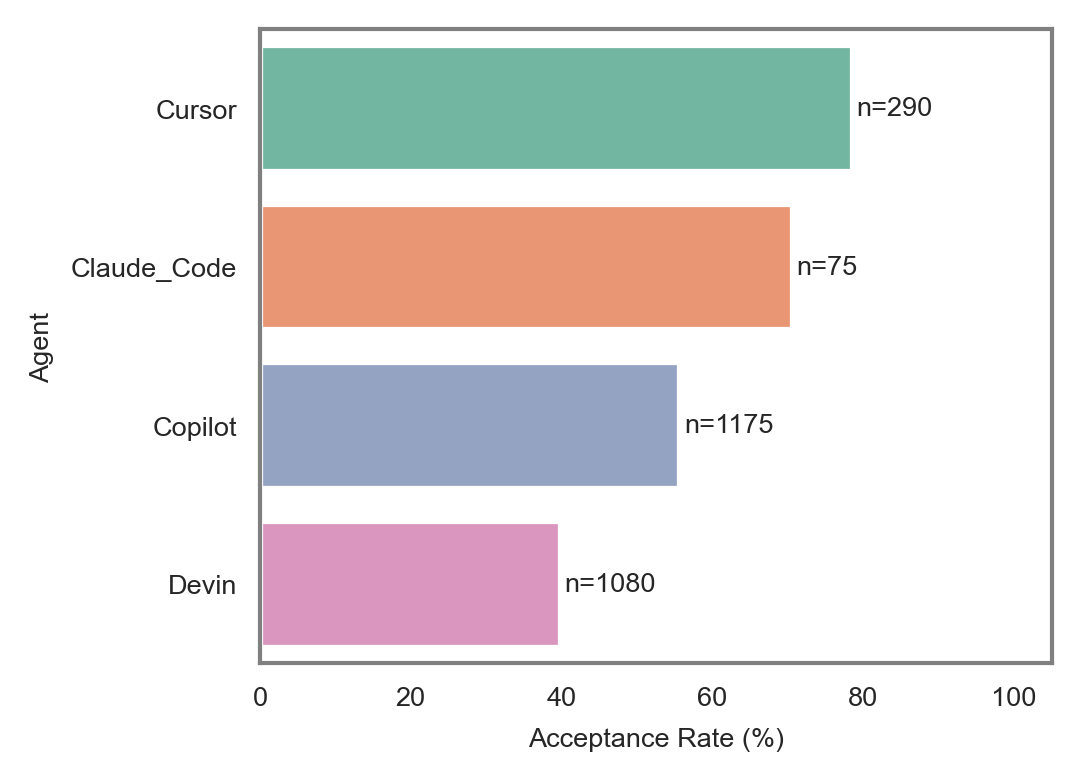

In [8]:
import os
os.makedirs('figs', exist_ok=True)

fig, ax = plt.subplots(figsize=(4, 3))

bars = sns.barplot(
    data=agent_stats,
    y='agent',
    x='acceptance_rate',
    palette='Set2',
    hue='agent',
    legend=False,
    ax=ax,
)

# Annotate bars with count
for i, row in agent_stats.iterrows():
    ax.text(
        row['acceptance_rate'] + 0.5,
        i,
        f"n={int(row['total'])}",
        va='center',
        fontsize=_BASE_FONT,
    )

ax.set_xlabel('Acceptance Rate (%)')
ax.set_ylabel('Agent')
ax.set_xlim(0, 105)
ax.grid(False)
fig.tight_layout()

plt.savefig('figs/own_data_acceptance_rate_by_agent.pdf', bbox_inches='tight', pad_inches=0.01, dpi=300)
plt.show()

## 9. Statistical Summary Table

In [9]:
summary = agent_stats[['agent', 'total', 'merged', 'rejected', 'acceptance_rate']].copy()
summary.columns = ['Agent', 'Total Fix PRs', 'Merged', 'Rejected', 'Acceptance Rate (\\%)']
summary['Acceptance Rate (\\%)'] = summary['Acceptance Rate (\\%)'].map(lambda x: f"{x:.2f}")

# Add overall row
summary.loc[len(summary)] = [
    '\\textbf{Overall}',
    total_closed,
    int(merged_count),
    int(rejected_count),
    f"{acceptance_rate:.2f}",
]

print(summary.to_string(index=False))

# Export as LaTeX
latex_table = summary.to_latex(
    index=False,
    caption='Acceptance Rate of Fix-Type Agentic Pull Requests by Agent (Own Data)',
    label='tab:own_data_acceptance_rate_fixes',
    position='!h',
    escape=False,
)
print("\n" + latex_table)

           Agent  Total Fix PRs  Merged  Rejected Acceptance Rate (\%)
          Cursor            290     228        62                78.62
     Claude_Code             75      53        22                70.67
         Copilot           1175     655       520                55.74
           Devin           1080     431       649                39.91
\textbf{Overall}           2620    1367      1253                52.18

\begin{table}[!h]
\caption{Acceptance Rate of Fix-Type Agentic Pull Requests by Agent (Own Data)}
\label{tab:own_data_acceptance_rate_fixes}
\begin{tabular}{lrrrl}
\toprule
Agent & Total Fix PRs & Merged & Rejected & Acceptance Rate (\%) \\
\midrule
Cursor & 290 & 228 & 62 & 78.62 \\
Claude_Code & 75 & 53 & 22 & 70.67 \\
Copilot & 1175 & 655 & 520 & 55.74 \\
Devin & 1080 & 431 & 649 & 39.91 \\
\textbf{Overall} & 2620 & 1367 & 1253 & 52.18 \\
\bottomrule
\end{tabular}
\end{table}



## 10. Rest Period: Same AIDev Repos, After AIDev Time Range → Feb 2026

In [10]:
# Get AIDev end date and repos as cutoff
aidev['created_at'] = pd.to_datetime(aidev['created_at'], errors='coerce')
aidev_max_date = aidev['created_at'].max()
aidev_repos = set(aidev['repo_name'].unique())

print(f"AIDev last date: {aidev_max_date}")
print(f"AIDev repos: {len(aidev_repos):,}")

# Filter our data: same AIDev repos, after AIDev ends, up to Feb 2026
rest_prs = classified_df[
    (classified_df['repo_name'].isin(aidev_repos)) &
    (classified_df['created_at'] > aidev_max_date) &
    (classified_df['created_at'] <= '2026-02-28')
].copy()

rest_prs['accepted'] = rest_prs['merged_at'].notna()

print(f"\nRest period PRs (AIDev repos, {aidev_max_date.strftime('%Y-%m-%d')} → 2026-02-28): {len(rest_prs):,}")
print(f"Repos: {rest_prs['repo_name'].nunique():,}")
print(f"\nAgent distribution:\n{rest_prs['agent'].value_counts()}")

AIDev last date: 2025-07-30 14:09:53+00:00
AIDev repos: 791

Rest period PRs (AIDev repos, 2025-07-30 → 2026-02-28): 17,421
Repos: 496

Agent distribution:
agent
Cursor         7254
Copilot        4709
Claude_Code    4613
Devin           845
Name: count, dtype: int64


In [11]:
# Rest period acceptance rate
rest_total = len(rest_prs)
rest_merged = rest_prs['accepted'].sum()
rest_rejected = rest_total - rest_merged
rest_rate = (rest_merged / rest_total) * 100

print("=" * 60)
print("REST PERIOD ACCEPTANCE RATE (Same Repos, Post-AIDev)")
print("=" * 60)
print(f"Time range:            {aidev_max_date.strftime('%Y-%m-%d')} → 2026-02-28")
print(f"Total closed fix PRs:  {rest_total:,}")
print(f"Merged (accepted):     {rest_merged:,}")
print(f"Not merged (rejected): {rest_rejected:,}")
print(f"Acceptance rate:       {rest_rate:.2f}%")
print("=" * 60)

REST PERIOD ACCEPTANCE RATE (Same Repos, Post-AIDev)
Time range:            2025-07-30 → 2026-02-28
Total closed fix PRs:  17,421
Merged (accepted):     13,938
Not merged (rejected): 3,483
Acceptance rate:       80.01%


In [12]:
# Rest period: acceptance rate by agent
rest_agent_stats = rest_prs.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()

rest_agent_stats['rejected'] = rest_agent_stats['total'] - rest_agent_stats['merged']
rest_agent_stats['acceptance_rate'] = (rest_agent_stats['merged'] / rest_agent_stats['total']) * 100
rest_agent_stats = rest_agent_stats.sort_values('acceptance_rate', ascending=False).reset_index(drop=True)

rest_agent_stats

,agent,total,merged,rejected,acceptance_rate
0,Cursor,7254,6406,848,88.309898
1,Claude_Code,4613,3994,619,86.581400
2,Copilot,4709,3043,1666,64.620939
3,Devin,845,495,350,58.579882


## 11. Full Comparison: AIDev Period vs Rest Period

In [13]:
# Side-by-side comparison
print("=" * 80)
print("FULL COMPARISON: AIDev Period vs Rest Period (Same Repos)")
print("=" * 80)

# Per-agent comparison
all_agents = sorted(set(agent_stats['agent'].tolist()) | set(rest_agent_stats['agent'].tolist()))

rows = []
for ag in all_agents:
    aidev_row = agent_stats[agent_stats['agent'] == ag]
    rest_row = rest_agent_stats[rest_agent_stats['agent'] == ag]
    rows.append({
        'Agent': ag,
        'AIDev Total': int(aidev_row['total'].values[0]) if len(aidev_row) else 0,
        'AIDev Rate (%)': f"{aidev_row['acceptance_rate'].values[0]:.2f}" if len(aidev_row) else 'N/A',
        'Rest Total': int(rest_row['total'].values[0]) if len(rest_row) else 0,
        'Rest Rate (%)': f"{rest_row['acceptance_rate'].values[0]:.2f}" if len(rest_row) else 'N/A',
    })

# Add overall row
rows.append({
    'Agent': 'OVERALL',
    'AIDev Total': total_closed,
    'AIDev Rate (%)': f"{acceptance_rate:.2f}",
    'Rest Total': rest_total,
    'Rest Rate (%)': f"{rest_rate:.2f}",
})

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

print(f"\n{'─' * 80}")
print(f"AIDev period:  {total_closed:,} PRs → {acceptance_rate:.2f}% acceptance")
print(f"Rest period:   {rest_total:,} PRs → {rest_rate:.2f}% acceptance")
print(f"{'─' * 80}")

FULL COMPARISON: AIDev Period vs Rest Period (Same Repos)
      Agent  AIDev Total AIDev Rate (%)  Rest Total Rest Rate (%)
Claude_Code           75          70.67        4613         86.58
    Copilot         1175          55.74        4709         64.62
     Cursor          290          78.62        7254         88.31
      Devin         1080          39.91         845         58.58
    OVERALL         2620          52.18       17421         80.01

────────────────────────────────────────────────────────────────────────────────
AIDev period:  2,620 PRs → 52.18% acceptance
Rest period:   17,421 PRs → 80.01% acceptance
────────────────────────────────────────────────────────────────────────────────


## 12. Apple-to-Apple Comparison (Same Repos, Same Selection Logic, Different Time Windows)

Both periods use **all our PRs** from the 791 AIDev repos — the only difference is the time window:
- **AIDev period**: AIDev min date → AIDev max date
- **Rest period**: AIDev max date → Feb 2026

In [14]:
# AIDev time boundaries
aidev_min_date = aidev['created_at'].min()
print(f"AIDev time range: {aidev_min_date} → {aidev_max_date}")
print(f"AIDev repos: {len(aidev_repos):,}")

# --- AIDev period: our PRs from AIDev repos, during AIDev time range ---
aidev_period_prs = classified_df[
    (classified_df['repo_name'].isin(aidev_repos)) &
    (classified_df['created_at'] >= aidev_min_date) &
    (classified_df['created_at'] <= aidev_max_date)
].copy()
aidev_period_prs['accepted'] = aidev_period_prs['merged_at'].notna()

# --- Rest period: already computed as rest_prs ---
print(f"\nAIDev period (our data): {len(aidev_period_prs):,} PRs from {aidev_period_prs['repo_name'].nunique():,} repos")
print(f"Rest period  (our data): {len(rest_prs):,} PRs from {rest_prs['repo_name'].nunique():,} repos")

AIDev time range: 2024-12-24 16:24:00+00:00 → 2025-07-30 14:09:53+00:00
AIDev repos: 791

AIDev period (our data): 15,056 PRs from 718 repos
Rest period  (our data): 17,421 PRs from 496 repos


In [15]:
# --- Acceptance rates for both periods ---
# AIDev period
ap_total = len(aidev_period_prs)
ap_merged = aidev_period_prs['accepted'].sum()
ap_rate = (ap_merged / ap_total) * 100

# Rest period (already computed, reuse rest_prs)
rp_total = len(rest_prs)
rp_merged = rest_prs['accepted'].sum()
rp_rate = (rp_merged / rp_total) * 100

print("=" * 65)
print("APPLE-TO-APPLE: Same Repos, Same Logic, Different Time Windows")
print("=" * 65)
print(f"AIDev period ({aidev_min_date.strftime('%Y-%m-%d')} → {aidev_max_date.strftime('%Y-%m-%d')}):")
print(f"  Total: {ap_total:,}  |  Merged: {int(ap_merged):,}  |  Rate: {ap_rate:.2f}%")
print(f"Rest period  ({aidev_max_date.strftime('%Y-%m-%d')} → 2026-02-28):")
print(f"  Total: {rp_total:,}  |  Merged: {int(rp_merged):,}  |  Rate: {rp_rate:.2f}%")
print("=" * 65)

APPLE-TO-APPLE: Same Repos, Same Logic, Different Time Windows
AIDev period (2024-12-24 → 2025-07-30):
  Total: 15,056  |  Merged: 12,152  |  Rate: 80.71%
Rest period  (2025-07-30 → 2026-02-28):
  Total: 17,421  |  Merged: 13,938  |  Rate: 80.01%


In [16]:
# --- Per-agent comparison (apple-to-apple) ---
ap_agent = aidev_period_prs.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()
ap_agent['acceptance_rate'] = (ap_agent['merged'] / ap_agent['total']) * 100

rp_agent = rest_prs.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()
rp_agent['acceptance_rate'] = (rp_agent['merged'] / rp_agent['total']) * 100

# Build comparison table
all_ag = sorted(set(ap_agent['agent'].tolist()) | set(rp_agent['agent'].tolist()))

comp_rows = []
for ag in all_ag:
    ap_r = ap_agent[ap_agent['agent'] == ag]
    rp_r = rp_agent[rp_agent['agent'] == ag]
    comp_rows.append({
        'Agent': ag,
        'AIDev Period Total': int(ap_r['total'].values[0]) if len(ap_r) else 0,
        'AIDev Period Rate (%)': f"{ap_r['acceptance_rate'].values[0]:.2f}" if len(ap_r) else 'N/A',
        'Rest Period Total': int(rp_r['total'].values[0]) if len(rp_r) else 0,
        'Rest Period Rate (%)': f"{rp_r['acceptance_rate'].values[0]:.2f}" if len(rp_r) else 'N/A',
    })

comp_rows.append({
    'Agent': 'OVERALL',
    'AIDev Period Total': ap_total,
    'AIDev Period Rate (%)': f"{ap_rate:.2f}",
    'Rest Period Total': rp_total,
    'Rest Period Rate (%)': f"{rp_rate:.2f}",
})

apple_comparison_df = pd.DataFrame(comp_rows)

print("APPLE-TO-APPLE COMPARISON BY AGENT")
print("=" * 80)
print(apple_comparison_df.to_string(index=False))
print(f"\n{'─' * 80}")
print(f"AIDev period:  {ap_total:,} PRs → {ap_rate:.2f}% acceptance")
print(f"Rest period:   {rp_total:,} PRs → {rp_rate:.2f}% acceptance")
print(f"{'─' * 80}")

APPLE-TO-APPLE COMPARISON BY AGENT
      Agent  AIDev Period Total AIDev Period Rate (%)  Rest Period Total Rest Period Rate (%)
Claude_Code                4457                 84.56               4613                86.58
    Copilot                1846                 58.23               4709                64.62
     Cursor                7545                 90.25               7254                88.31
      Devin                1208                 41.31                845                58.58
    OVERALL               15056                 80.71              17421                80.01

────────────────────────────────────────────────────────────────────────────────
AIDev period:  15,056 PRs → 80.71% acceptance
Rest period:   17,421 PRs → 80.01% acceptance
────────────────────────────────────────────────────────────────────────────────


## 13. Rest Period for Matched-Key Repos Only

Uses only the repos that appear in the 2,620 matched PRs (not all 791 AIDev repos).
- **AIDev period**: 2,620 matched PRs → 52.18%
- **Rest period**: All our PRs from those same repos, after AIDev ends → Feb 2026

In [17]:
# Repos from the 2,620 matched PRs
matched_repos = set(fix_prs['repo_name'].unique())
print(f"Repos with matched PRs: {len(matched_repos):,} (out of {len(aidev_repos):,} AIDev repos)")

# Rest period: same matched repos, after AIDev ends, up to Feb 2026
rest_matched = classified_df[
    (classified_df['repo_name'].isin(matched_repos)) &
    (classified_df['created_at'] > aidev_max_date) &
    (classified_df['created_at'] <= '2026-02-28')
].copy()
rest_matched['accepted'] = rest_matched['merged_at'].notna()

rm_total = len(rest_matched)
rm_merged = rest_matched['accepted'].sum()
rm_rate = (rm_merged / rm_total) * 100

print(f"\n{'=' * 70}")
print(f"REST PERIOD (Matched-Key Repos, {aidev_max_date.strftime('%Y-%m-%d')} → 2026-02-28)")
print(f"{'=' * 70}")
print(f"Total closed fix PRs:  {rm_total:,}")
print(f"Merged (accepted):     {int(rm_merged):,}")
print(f"Not merged (rejected): {rm_total - int(rm_merged):,}")
print(f"Acceptance rate:       {rm_rate:.2f}%")
print(f"Repos:                 {rest_matched['repo_name'].nunique():,}")
print(f"{'=' * 70}")
print(f"\nAgent distribution:\n{rest_matched['agent'].value_counts()}")

Repos with matched PRs: 682 (out of 791 AIDev repos)

REST PERIOD (Matched-Key Repos, 2025-07-30 → 2026-02-28)
Total closed fix PRs:  16,507
Merged (accepted):     13,176
Not merged (rejected): 3,331
Acceptance rate:       79.82%
Repos:                 444

Agent distribution:
agent
Cursor         6650
Copilot        4552
Claude_Code    4460
Devin           845
Name: count, dtype: int64


In [18]:
# Per-agent comparison: matched period vs rest period (matched repos)
rm_agent = rest_matched.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()
rm_agent['acceptance_rate'] = (rm_agent['merged'] / rm_agent['total']) * 100

all_matched_agents = sorted(set(agent_stats['agent'].tolist()) | set(rm_agent['agent'].tolist()))

matched_rows = []
for ag in all_matched_agents:
    m_row = agent_stats[agent_stats['agent'] == ag]
    r_row = rm_agent[rm_agent['agent'] == ag]
    matched_rows.append({
        'Agent': ag,
        'Matched Total': int(m_row['total'].values[0]) if len(m_row) else 0,
        'Matched Rate (%)': f"{m_row['acceptance_rate'].values[0]:.2f}" if len(m_row) else 'N/A',
        'Rest Total': int(r_row['total'].values[0]) if len(r_row) else 0,
        'Rest Rate (%)': f"{r_row['acceptance_rate'].values[0]:.2f}" if len(r_row) else 'N/A',
    })

matched_rows.append({
    'Agent': 'OVERALL',
    'Matched Total': total_closed,
    'Matched Rate (%)': f"{acceptance_rate:.2f}",
    'Rest Total': rm_total,
    'Rest Rate (%)': f"{rm_rate:.2f}",
})

matched_comp_df = pd.DataFrame(matched_rows)

print("MATCHED-KEY REPOS: AIDev Period vs Rest Period")
print("=" * 80)
print(matched_comp_df.to_string(index=False))
print(f"\n{'─' * 80}")
print(f"AIDev period (matched):  {total_closed:,} PRs → {acceptance_rate:.2f}% acceptance")
print(f"Rest period (same repos): {rm_total:,} PRs → {rm_rate:.2f}% acceptance")
print(f"{'─' * 80}")

MATCHED-KEY REPOS: AIDev Period vs Rest Period
      Agent  Matched Total Matched Rate (%)  Rest Total Rest Rate (%)
Claude_Code             75            70.67        4460         86.75
    Copilot           1175            55.74        4552         64.85
     Cursor            290            78.62        6650         88.12
      Devin           1080            39.91         845         58.58
    OVERALL           2620            52.18       16507         79.82

────────────────────────────────────────────────────────────────────────────────
AIDev period (matched):  2,620 PRs → 52.18% acceptance
Rest period (same repos): 16,507 PRs → 79.82% acceptance
────────────────────────────────────────────────────────────────────────────────


## 14. Stratified Sampling: Same Size & Agent Mix

Sample the rest period to **exactly match** the AIDev period's PR count per agent (2,620 total).
This controls for both sample size and agent composition (Simpson's Paradox).

In [19]:
# Agent counts from matched AIDev period (2,620 PRs)
aidev_agent_counts = fix_prs.groupby('agent').size()
print("AIDev period agent counts (target):")
print(aidev_agent_counts)
print(f"Total: {aidev_agent_counts.sum():,}")

# Stratified sample from rest_matched: same count per agent
sampled_parts = []
shortfall = {}
for agent, target_n in aidev_agent_counts.items():
    pool = rest_matched[rest_matched['agent'] == agent]
    available = len(pool)
    n = min(target_n, available)
    if available < target_n:
        shortfall[agent] = target_n - available
    sampled_parts.append(pool.sample(n=n, random_state=42))

rest_sampled = pd.concat(sampled_parts, ignore_index=True)
rest_sampled['accepted'] = rest_sampled['merged_at'].notna()

print(f"\nStratified sample: {len(rest_sampled):,} PRs")
if shortfall:
    print(f"⚠ Agents with fewer PRs than target: {shortfall}")
print(f"\nSampled agent distribution:\n{rest_sampled['agent'].value_counts()}")

AIDev period agent counts (target):
agent
Claude_Code      75
Copilot        1175
Cursor          290
Devin          1080
dtype: int64
Total: 2,620

Stratified sample: 2,385 PRs
⚠ Agents with fewer PRs than target: {'Devin': 235}

Sampled agent distribution:
agent
Copilot        1175
Devin           845
Cursor          290
Claude_Code      75
Name: count, dtype: int64


In [20]:
# Compare: same size, same agent mix
rs_total = len(rest_sampled)
rs_merged = rest_sampled['accepted'].sum()
rs_rate = (rs_merged / rs_total) * 100

rs_agent = rest_sampled.groupby('agent').agg(
    total=('accepted', 'count'),
    merged=('accepted', 'sum')
).reset_index()
rs_agent['acceptance_rate'] = (rs_agent['merged'] / rs_agent['total']) * 100

# Build comparison table
strat_agents = sorted(set(agent_stats['agent'].tolist()) | set(rs_agent['agent'].tolist()))

strat_rows = []
for ag in strat_agents:
    a_row = agent_stats[agent_stats['agent'] == ag]
    s_row = rs_agent[rs_agent['agent'] == ag]
    strat_rows.append({
        'Agent': ag,
        'AIDev N': int(a_row['total'].values[0]) if len(a_row) else 0,
        'AIDev Rate (%)': f"{a_row['acceptance_rate'].values[0]:.2f}" if len(a_row) else 'N/A',
        'Rest N': int(s_row['total'].values[0]) if len(s_row) else 0,
        'Rest Rate (%)': f"{s_row['acceptance_rate'].values[0]:.2f}" if len(s_row) else 'N/A',
    })

strat_rows.append({
    'Agent': 'OVERALL',
    'AIDev N': total_closed,
    'AIDev Rate (%)': f"{acceptance_rate:.2f}",
    'Rest N': rs_total,
    'Rest Rate (%)': f"{rs_rate:.2f}",
})

strat_df = pd.DataFrame(strat_rows)

print("STRATIFIED COMPARISON: Same Size, Same Agent Mix")
print("=" * 80)
print(strat_df.to_string(index=False))
print(f"\n{'─' * 80}")
print(f"AIDev period:               {total_closed:,} PRs → {acceptance_rate:.2f}%")
print(f"Rest period:   {rs_total:,} PRs → {rs_rate:.2f}%")
print(f"{'─' * 80}")
print(f"\nDifference: {rs_rate - acceptance_rate:+.2f} percentage points")

STRATIFIED COMPARISON: Same Size, Same Agent Mix
      Agent  AIDev N AIDev Rate (%)  Rest N Rest Rate (%)
Claude_Code       75          70.67      75         89.33
    Copilot     1175          55.74    1175         64.34
     Cursor      290          78.62     290         87.93
      Devin     1080          39.91     845         58.58
    OVERALL     2620          52.18    2385         65.95

────────────────────────────────────────────────────────────────────────────────
AIDev period:               2,620 PRs → 52.18%
Rest period:   2,385 PRs → 65.95%
────────────────────────────────────────────────────────────────────────────────

Difference: +13.78 percentage points
